In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Dense, 
    GlobalAveragePooling2D, 
    Dropout, 
    InputLayer, 
    Flatten 
)
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image_dataset_from_directory


from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_curve
)

from tqdm import tqdm
import seaborn as sns

In [3]:
BATCH_SIZE = 32
IMAGE_SIZE = 24
CHANNELS = 3
EPOCHS = 5
PATH = "E:\Drowsiness-Detection\Drowsines_Dataset"

In [4]:
train_ds = image_dataset_from_directory(
    PATH,
    seed = 42,
    shuffle = True,
    image_size = (IMAGE_SIZE , IMAGE_SIZE),
    batch_size = BATCH_SIZE,
    validation_split = 0.2,
    subset = 'training'

)

val_test_ds = image_dataset_from_directory(
    PATH,
    seed = 42,
    shuffle = True,
    image_size = (IMAGE_SIZE , IMAGE_SIZE),
    batch_size = BATCH_SIZE,
    validation_split = 0.2,
    subset = 'validation'

)

Found 48000 files belonging to 2 classes.
Using 38400 files for training.
Found 48000 files belonging to 2 classes.
Using 9600 files for validation.


In [5]:
val_test_size = val_test_ds.cardinality().numpy()
val_size = val_test_size // 2 

val_ds = val_test_ds.take(val_size)   
test_ds = val_test_ds.skip(val_size)   


In [6]:
class_names = train_ds.class_names
class_names

['closed_eye', 'open_eye']

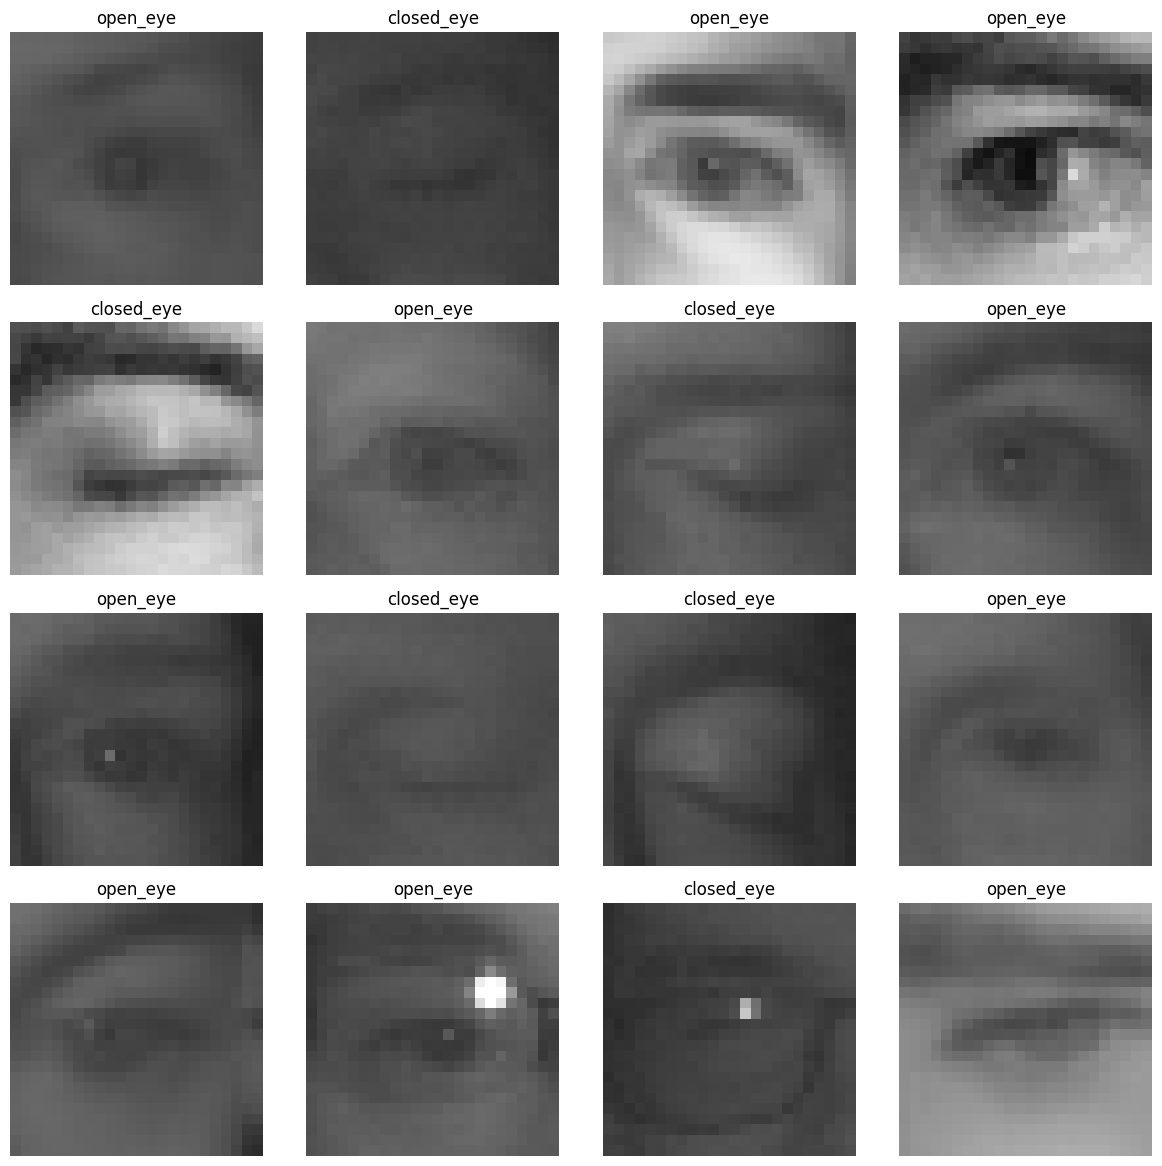

In [7]:
plt.figure(figsize=(12, 12))
for batch_images, batch_labels in train_ds.take(1):
    for i in range(16):
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(batch_images[i].numpy().astype("uint8"))
        plt.title(class_names[batch_labels[i]])
        plt.tight_layout()
        plt.axis("off")


In [8]:
resize_and_rescale = tf.keras.Sequential([
  layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
  layers.Rescaling(1./255), # 0-1 range 
])

In [9]:
data_augmentation = tf.keras.Sequential([
  layers.RandomRotation(0.2), # 0.2= rotate factor
  layers.RandomFlip(seed = 42) 
])

In [10]:
train_data = train_ds.map( 
    lambda x, y: (data_augmentation(x, training=True), y)           
).prefetch(buffer_size=tf.data.AUTOTUNE)  